In [164]:
#import keras
import tensorflow as tf
from tensorflow import keras
from IPython.display import Image
import matplotlib.pyplot as plt
#from keras import layers
#from keras import ops
from tensorflow.keras import layers
import os


In [165]:

train_ds = tf.keras.utils.image_dataset_from_directory(
    "rps-cv-images",
    validation_split=0.30,
    subset="training",
    seed=42,
    color_mode="grayscale",
    image_size=(200,200),
    batch_size=32
)

temp_ds = tf.keras.utils.image_dataset_from_directory(
    "rps-cv-images",
    validation_split=0.30,
    subset="validation",
    seed=42,
    color_mode="grayscale",
    image_size=(200,200),
    batch_size=32
)

temp_size = len(temp_ds)

val_size = temp_size // 2

val_ds = temp_ds.take(val_size)
test_ds = temp_ds.skip(val_size)


Found 2188 files belonging to 3 classes.
Using 1532 files for training.
Found 2188 files belonging to 3 classes.
Using 656 files for validation.


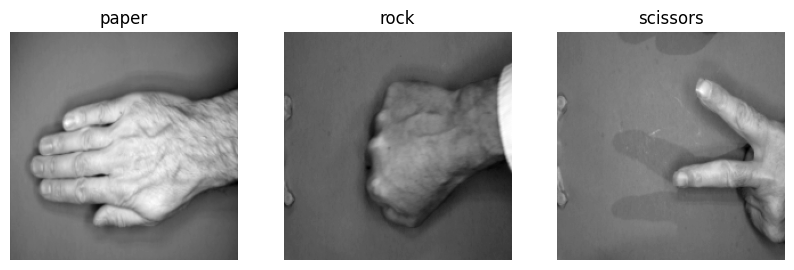

In [166]:
class_names = train_ds.class_names
# Display one image per class
shown_classes = set()
plt.figure(figsize=(10, 4))
for images, labels in train_ds.unbatch():
    label = labels.numpy()
    if label not in shown_classes:
        plt.subplot(1, len(class_names), len(shown_classes) + 1)
        plt.imshow(images.numpy().squeeze(), cmap="gray")  
        plt.title(class_names[label])
        plt.axis("off")
        shown_classes.add(label)
    if len(shown_classes) == len(class_names):
        break
plt.show()

In [196]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.2),
   
])

In [ ]:
model_1 = keras.Sequential(
    [
    #data_augmentation,
    layers.Rescaling(1./255),
    layers.Resizing(96, 96),        
   layers.Conv2D(24, (3, 3), activation="relu",kernel_initializer='he_normal', input_shape=(96, 96, 1)),
   layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation="relu",kernel_initializer='he_normal'),
    layers.Dense(3,activation='softmax')

    ]
)

In [191]:
model_1.summary()


Model: "sequential_30"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_25 (Sequential)      │ (None, 200, 200, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_24 (Rescaling)        │ (None, 200, 200, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing_7 (Resizing)           │ (None, 96, 96, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_69 (Conv2D)              │ (None, 94, 94, 24)     │           240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_69 (MaxPooling2D) │ (None, 47, 47, 24)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_24 (Flatten)            │ (None, 53016)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_56 (Dense)                │ (None, 64)             │     3,393,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_57 (Dense)                │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,393,523 (12.95 MB)

 Trainable params: 3,393,523 (12.95 MB)

 Non-trainable params: 0 (0.00 B)

In [192]:
model_1.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [193]:
model_1.fit(train_ds, validation_data=val_ds, epochs=10)

Epoch 1/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.3476 - loss: 5.5247 - val_accuracy: 0.4969 - val_loss: 1.0336
Epoch 2/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.4457 - loss: 1.0637 - val_accuracy: 0.3594 - val_loss: 1.2797
Epoch 3/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.4478 - loss: 1.1001 - val_accuracy: 0.6719 - val_loss: 0.8421
Epoch 4/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.6077 - loss: 0.8687 - val_accuracy: 0.7188 - val_loss: 0.7687
Epoch 5/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.6796 - loss: 0.8123 - val_accuracy: 0.8125 - val_loss: 0.7126
Epoch 6/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.6637 - loss: 0.8682 - val_accuracy: 0.5938 - val_loss: 1.1411
Epoch 7/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.6096 - loss: 1.1103 - val_accuracy: 0.8687 - val_loss: 0.6332
Epoch 8/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.7705 - loss: 0.7328 - val_accuracy: 0.6594 - v

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
Predicted label: scissors
Actual label: scissors


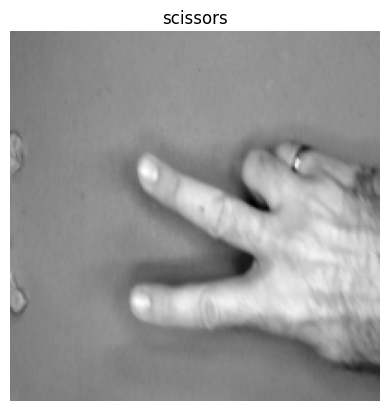

In [194]:
for images, labels in test_ds.take(1):
    
    image = images[0].numpy()
    label = labels[0].numpy()
    prediction = model_1.predict(image[None, ...])

    print(f"Predicted label: {class_names[prediction.argmax()]}")
    print(f"Actual label: {class_names[label]}")

    plt.imshow(image.squeeze(), cmap="gray")
    plt.title(class_names[label])
    plt.axis("off")
    plt.show()

In [195]:
model_1.evaluate(test_ds)

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7997 - loss: 0.5985 


[0.6096799969673157, 0.8035714030265808]

In [174]:
model_2 = keras.Sequential(
    [
        data_augmentation,
    layers.Rescaling(1./255),
   layers.Conv2D(16, (3, 3), activation="relu",kernel_initializer='he_normal', input_shape=(128, 128, 1)),
   layers.MaxPooling2D((2, 2)),
   layers.Conv2D(32, (3, 3), activation="relu",kernel_initializer='he_normal'),
   layers.MaxPooling2D((2, 2)),
   layers.Conv2D(64, (3, 3), activation="relu",kernel_initializer='he_normal'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation="relu",kernel_initializer='he_normal'),
    layers.Dense(84, activation="relu",kernel_initializer='he_normal'),

    layers.Dense(3,activation='softmax')

    ]
)

In [175]:
model_2.summary()


Model: "sequential_27"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_25 (Sequential)      │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_21 (Rescaling)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_61 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_61 (MaxPooling2D) │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_62 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_62 (MaxPooling2D) │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_63 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_63 (MaxPooling2D) │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_21 (Flatten)            │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_49 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_50 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_51 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [176]:
model_2.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [177]:
model_2.fit(train_ds, validation_data=val_ds, epochs=10)

Epoch 1/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 5s 77ms/step - accuracy: 0.3728 - loss: 3.3553 - val_accuracy: 0.6906 - val_loss: 0.7582
Epoch 2/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 4s 77ms/step - accuracy: 0.7393 - loss: 0.6708 - val_accuracy: 0.8813 - val_loss: 0.4184
Epoch 3/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 4s 78ms/step - accuracy: 0.8602 - loss: 0.4021 - val_accuracy: 0.9281 - val_loss: 0.2497
Epoch 4/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 4s 79ms/step - accuracy: 0.9067 - loss: 0.2961 - val_accuracy: 0.9344 - val_loss: 0.2165
Epoch 5/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 4s 79ms/step - accuracy: 0.9335 - loss: 0.2318 - val_accuracy: 0.9187 - val_loss: 0.2485
Epoch 6/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 4s 80ms/step - accuracy: 0.9373 - loss: 0.1742 - val_accuracy: 0.9469 - val_loss: 0.1525
Epoch 7/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 4s 79ms/step - accuracy: 0.9475 - loss: 0.1634 - val_accuracy: 0.9719 - val_loss: 0.0725
Epoch 8/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 4s 80ms/step - accuracy: 0.9500 - loss: 0.1545 - val_accuracy: 0.9750 - v

In [178]:
model_2.evaluate(test_ds)

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9676 - loss: 0.0980


[0.10825404524803162, 0.9702380895614624]

In [179]:
model_3 = keras.Sequential([
    data_augmentation,
    layers.Rescaling(1./255),
    
    layers.Conv2D(16, (7, 7), activation="relu",kernel_initializer='he_normal', input_shape=(200, 200, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(32, (5, 5), activation="relu",kernel_initializer='he_normal'),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(64, (3, 3), activation="relu",kernel_initializer='he_normal'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu',kernel_initializer='he_normal'),
    layers.MaxPooling2D((2, 2)),
    
    
    layers.Flatten(),
    layers.Dense(128, activation="relu",name='dense_1',kernel_initializer='he_normal'),
    layers.Dropout(0.2),
    layers.Dense(64,activation='relu',kernel_initializer='he_normal'),
    layers.Dropout(0.2),
    layers.Dense(3, activation='softmax')
])

In [180]:
model_3.summary()


Model: "sequential_28"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_25 (Sequential)      │ (None, 200, 200, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_22 (Rescaling)        │ (None, 200, 200, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_64 (Conv2D)              │ (None, 194, 194, 16)   │           800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_64 (MaxPooling2D) │ (None, 97, 97, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_65 (Conv2D)              │ (None, 93, 93, 32)     │        12,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_65 (MaxPooling2D) │ (None, 46, 46, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_66 (Conv2D)              │ (None, 44, 44, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_66 (MaxPooling2D) │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_67 (Conv2D)              │ (None, 20, 20, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_67 (MaxPooling2D) │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_22 (Flatten)            │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │     1,638,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_52 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_53 (Dense)                │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,752,963 (6.69 MB)

 Trainable params: 1,752,963 (6.69 MB)

 Non-trainable params: 0 (0.00 B)

In [181]:
model_3.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
model_3.fit(train_ds, validation_data=val_ds, epochs=10)

Epoch 1/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 7s 112ms/step - accuracy: 0.3267 - loss: 1.6608 - val_accuracy: 0.5000 - val_loss: 1.0351
Epoch 2/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 5s 112ms/step - accuracy: 0.5608 - loss: 0.9072 - val_accuracy: 0.8188 - val_loss: 0.5081
Epoch 3/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 5s 111ms/step - accuracy: 0.7250 - loss: 0.6429 - val_accuracy: 0.8750 - val_loss: 0.3463
Epoch 4/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 5s 111ms/step - accuracy: 0.8583 - loss: 0.3669 - val_accuracy: 0.9656 - val_loss: 0.1397
Epoch 5/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 5s 111ms/step - accuracy: 0.9009 - loss: 0.3108 - val_accuracy: 0.9281 - val_loss: 0.1913
Epoch 6/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 5s 112ms/step - accuracy: 0.9376 - loss: 0.2002 - val_accuracy: 0.9750 - val_loss: 0.0951
Epoch 7/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 5s 114ms/step - accuracy: 0.9456 - loss: 0.1809 - val_accuracy: 0.9594 - val_loss: 0.1170
Epoch 8/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 6s 115ms/step - accuracy: 0.9490 - loss: 0.1458 - val_accuracy: 0.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
Predicted label: rock
Actual label: rock


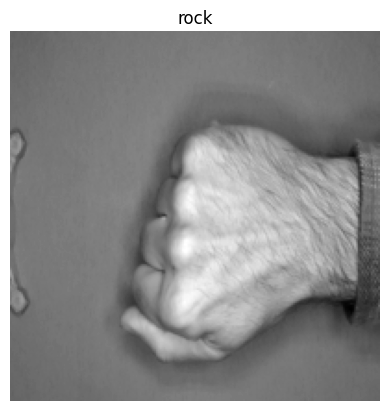

In [182]:
for images, labels in test_ds.take(1):
    
    image = images[0].numpy()
    label = labels[0].numpy()
    prediction = model_3.predict(image[None, ...])

    print(f"Predicted label: {class_names[prediction.argmax()]}")
    print(f"Actual label: {class_names[label]}")

    plt.imshow(image.squeeze(), cmap="gray")
    plt.title(class_names[label])
    plt.axis("off")
    plt.show()
    

In [183]:
model_3.evaluate(test_ds)

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.9707 - loss: 0.1102


[0.1113966777920723, 0.976190447807312]